In [ ]:
!pip install kaggle


In [ ]:
!pwd
!ls

/content
'archive (1).zip'  'archive (3).zip'  'archive (5).zip'   sample_data
'archive (2).zip'  'archive (4).zip'   datasets


In [ ]:
!mkdir datasets

In [ ]:
!mkdir datasets/brain
!mkdir datasets/lung
!mkdir datasets/breast
!mkdir datasets/skin
!mkdir datasets/kidney

mkdir: cannot create directory ‘datasets/brain’: File exists
mkdir: cannot create directory ‘datasets/lung’: File exists
mkdir: cannot create directory ‘datasets/breast’: File exists
mkdir: cannot create directory ‘datasets/skin’: File exists
mkdir: cannot create directory ‘datasets/kidney’: File exists


In [ ]:
!unzip 'archive (1).zip'-d datasets/brain


unzip:  cannot find or open archive (1).zip-d, archive (1).zip-d.zip or archive (1).zip-d.ZIP.


In [ ]:
!ls


'archive (1).zip'  'archive (3).zip'  'archive (5).zip'   sample_data
'archive (2).zip'  'archive (4).zip'   datasets


In [ ]:
ls -lh


total 2.6G
-rw-r--r-- 1 root root  16M Feb  9 04:45 'archive (1).zip'
-rw-r--r-- 1 root root 912M Feb  9 04:57 'archive (2).zip'
-rw-r--r-- 1 root root  49K Feb  9 04:46 'archive (3).zip'
-rw-r--r-- 1 root root 786M Feb  9 04:54 'archive (4).zip'
-rw-r--r-- 1 root root 850M Feb  9 04:57 'archive (5).zip'
drwxr-xr-x 7 root root 4.0K Feb  9 04:56  datasets/
drwxr-xr-x 1 root root 4.0K Dec  9 14:42  sample_data/


In [ ]:
!unzip "archive (1).zip" -d datasets/brain
!unzip "archive (2).zip" -d datasets/lung
!unzip "archive (3).zip" -d datasets/skin
!unzip "archive (4).zip" -d datasets/kidney
!unzip "archive (5).zip" -d datasets/breast


Archive:  archive (1).zip
replace datasets/brain/brain_tumor_dataset/no/1 no.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: datasets/brain/brain_tumor_dataset/no/1 no.jpeg  
  inflating: datasets/brain/brain_tumor_dataset/no/10 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/11 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/12 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/13 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/14 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/15 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/17 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/18 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/19 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/2 no.jpeg  
  inflating: datasets/brain/brain_tumor_dataset/no/20 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/21 no.jpg  
  inflating: datasets/brain/brain_tumor_dataset/no/22 no.j

In [27]:
!unzip 'archive (5).zip' -d datasets/breast


Archive:  archive (5).zip
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of archive (5).zip or
        archive (5).zip.zip, and cannot find archive (5).zip.ZIP, period.


In [ ]:
!ls *.zip

'archive (1).zip'  'archive (3).zip'  'archive (5).zip'
'archive (2).zip'  'archive (4).zip'


In [ ]:
!ls

'archive (1).zip'  'archive (3).zip'  'archive (5).zip'   sample_data
'archive (2).zip'  'archive (4).zip'   datasets


In [28]:
!ls datasets

brain  breast  kidney  lung  skin


In [29]:
!ls datasets/brain

brain_tumor_dataset  no  yes


In [36]:
!find datasets -type f | wc -l


2864


In [38]:
!find datasets -maxdepth 3 -type d


datasets
datasets/kidney
datasets/kidney/Skin cancer ISIC The International Skin Imaging Collaboration
datasets/kidney/Skin cancer ISIC The International Skin Imaging Collaboration/Train
datasets/kidney/Skin cancer ISIC The International Skin Imaging Collaboration/Test
datasets/breast
datasets/skin
datasets/brain
datasets/brain/yes
datasets/brain/brain_tumor_dataset
datasets/brain/brain_tumor_dataset/yes
datasets/brain/brain_tumor_dataset/no
datasets/brain/no
datasets/lung


In [57]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import matplotlib.pyplot as plt


In [58]:
dataset_path="datasets/brain"

In [59]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.1,
)

In [60]:
train_data =datagen .flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)


Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [49]:
!ls datasets/brain

brain_tumor_dataset  no  yes


In [50]:
!ls datasets/brain/brain_tumor_dataset

no  yes


In [52]:
!mv "datasets/brain/brain_tumor_dataset/yes/"* datasets/brain/yes/


In [53]:
!mv "datasets/brain/brain_tumor_dataset/no/"* datasets/brain/no/

In [54]:
!rm -r "datasets/brain/brain_tumor_dataset"

In [55]:
!ls datasets/brain

no  yes


In [61]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))  # Binary classification


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [63]:
history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data
)


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.4724 - loss: 3.0996 - val_accuracy: 0.6800 - val_loss: 0.6401
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 505ms/step - accuracy: 0.7835 - loss: 0.5587 - val_accuracy: 0.7400 - val_loss: 0.5173
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 494ms/step - accuracy: 0.7403 - loss: 0.5438 - val_accuracy: 0.7600 - val_loss: 0.6250
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - accuracy: 0.7889 - loss: 0.4830 - val_accuracy: 0.7000 - val_loss: 0.5916
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - accuracy: 0.7815 - loss: 0.5402 - val_accuracy: 0.7400 - val_loss: 0.5796
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 525ms/step - accuracy: 0.7910 - loss: 0.5078 - val_accuracy: 0.7400 - val_loss: 0.5285
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 398ms/step - accuracy: 0.8184 - loss: 0.4153 - val_accuracy: 0.7400 - val_loss: 0.5246
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 419ms/step - accuracy: 0.7817 - loss: 0.5111 - val_accuracy: 0.7800 - val_loss: 0

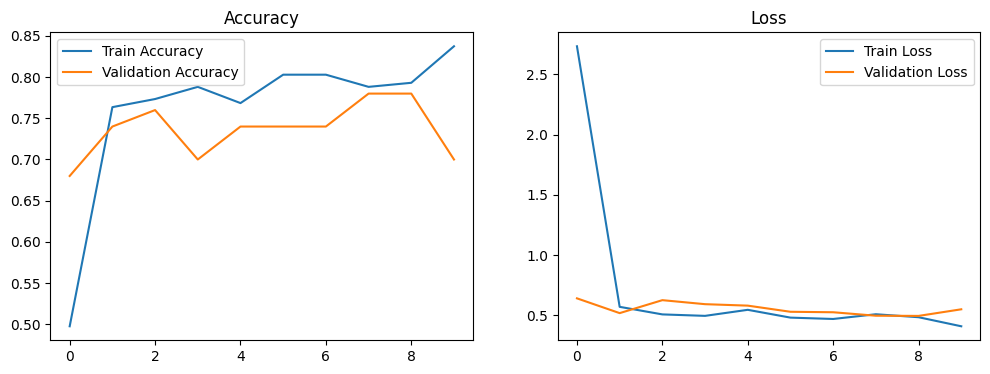

In [64]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [65]:
model.save("brain_tumor_model.h5")


In [70]:
from google.colab import files
files.upload()

Saving braintumorImage.png to braintumorImage.png


{'braintumorImage.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x10\xc6\x00\x00\x06\x88\x08\x00\x00\x00\x00T\x84:l\x00\x00\x00\x01sRGB\x00\xae\xce\x1c\xe9\x00\x00\x00\x02bKGD\x00\xff\x87\x8f\xcc\xbf\x00\x00\x00\tpHYs\x00\x00\\F\x00\x00\\F\x01\x14\x94CA\x00\x00\x00\x07tIME\x07\xe8\t\x17\x16\x0e\x1d\x133\xa0\x8d\x00\x00\x80\x00IDATx\xda\xec\xfd\xd9\x92$K\x92%\x88\x1df\x16QU3_b\xb9{fWvm]\x05T\x0f\xa1\x1b \x02\xcd\x00\x0fx\xc2\x87\x82\x08O\xf8\x01\xbc\r\x88\xe6\x01\x0fC\x83\x1e\xd0tM7\xa6\xa7\xab\xaak\xcb\xcc\x9bw\x89\xc5\x173SU\x11f<\x88\xee\xa6\xe6\xee\x117\xe2\xde\x08\x0f9\x94y\xc3M\x17QQ\xd1M\xf8\xc89,d\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xc8\xf8\x18\xc0\xbft\x052222222222222222\x1e\x86Lcddddddddddddddd|$\xc84FFFFFFFFFFFFFFF\xc6G\x82Lcddddddddddddddd|$\xc84FFFFFFFFFFFFFFF\xc6G\x82Lcddddddddddddddd|$\xc84FFFFFFFFFFFFFFF\xc6G\x82Lcddddddddddddddd|$\xc84FFFFFFFFFFFFFFF\xc6G\x82Lcddddddddddddddd|$\xc84FFFFFFFFFFFFFFF\xc6G\x82Lcddddddddddddddd|$\xc84FFFFFFFFFFF

In [74]:
ls

test_images/


In [76]:
ls test_images

'archive (1).zip'  'archive (4).zip'      brain_tumor_model.h5
'archive (2).zip'  'archive (5).zip'      datasets/
'archive (3).zip'   braintumorImage.png   sample_data/


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 990ms/step
🧠 Prediction: Tumor Detected


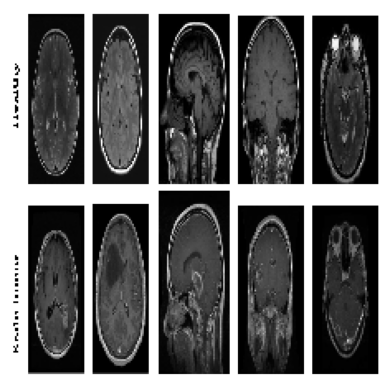

In [82]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/braintumorImage.png"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

plt.imshow(img)
plt.axis('off')

if prediction[0][0] > 0.5:
    print("🧠 Prediction: Tumor Detected")
else:
    print("🧠 Prediction: No Tumor")


In [83]:
mkdir test_skin

In [84]:
mv SkinCancerImage.jpg test_skin/

In [92]:
mv SkinCancer2.jpg test_skin/


In [91]:
mv skinCancer3.jpg test_skin/

In [89]:

mv skincancer4.jpg test_skin/

In [85]:
ls test_skin

SkinCancerImage.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
🧴 Benign Skin (58.93%)


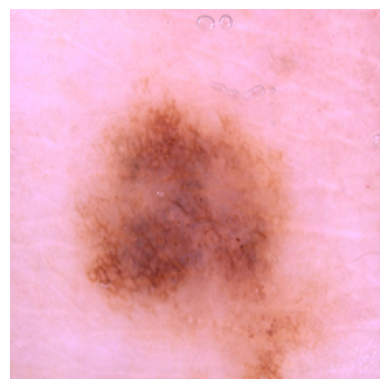

In [86]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

img_path = "/content/test_skin/SkinCancerImage.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
confidence = prediction[0][0] * 100

plt.imshow(img)
plt.axis('off')

if prediction[0][0] > 0.5:
    print(f"🧴 Skin Cancer Detected ({confidence:.2f}%)")
else:
    print(f"🧴 Benign Skin ({100-confidence:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


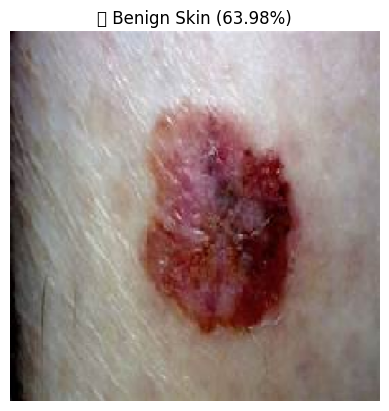

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


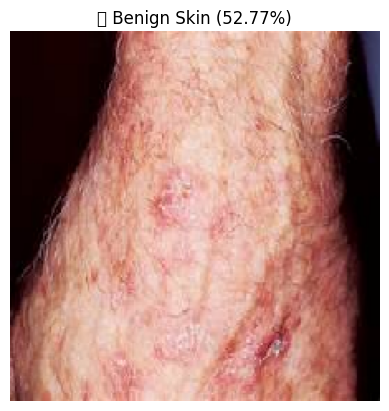

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


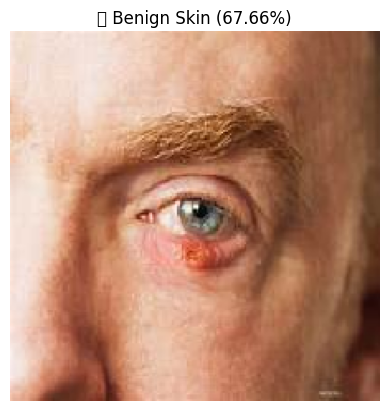

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


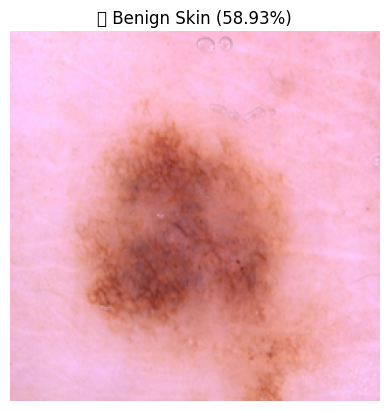

In [93]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

test_dir = "test_skin"

for img_name in os.listdir(test_dir):

    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    confidence = prediction[0][0] * 100

    plt.imshow(img)
    plt.axis("off")

    if prediction[0][0] > 0.5:
        plt.title(f"🔴 Skin Cancer Detected ({confidence:.2f}%)")
    else:
        plt.title(f"🟢 Benign Skin ({100-confidence:.2f}%)")

    plt.show()
